In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

import math
import warnings

warnings.filterwarnings("ignore")

pt = PowerTransformer(method= "yeo-johnson")


### First look at the data

In [2]:
train = pd.read_csv("train.csv")
test =  pd.read_csv("test.csv")
samples = pd.read_csv("sample_submission.csv")
copy = train.copy()

In [3]:
copy.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [4]:
print(f"Number of rows : {copy.shape[0]}")
print(f"Number of columns : {copy.shape[1]}")


Number of rows : 1460
Number of columns : 81


In [5]:
copy.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQ

In [6]:
copy.drop("Id", axis= 1, inplace= True)
test.drop("Id", axis= 1, inplace= True)
samples.drop("Id", axis= 1, inplace= True)

In [7]:
copy.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
copy.columns.sort_values().to_list()


['1stFlrSF',
 '2ndFlrSF',
 '3SsnPorch',
 'Alley',
 'BedroomAbvGr',
 'BldgType',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtFinType1',
 'BsmtFinType2',
 'BsmtFullBath',
 'BsmtHalfBath',
 'BsmtQual',
 'BsmtUnfSF',
 'CentralAir',
 'Condition1',
 'Condition2',
 'Electrical',
 'EnclosedPorch',
 'ExterCond',
 'ExterQual',
 'Exterior1st',
 'Exterior2nd',
 'Fence',
 'FireplaceQu',
 'Fireplaces',
 'Foundation',
 'FullBath',
 'Functional',
 'GarageArea',
 'GarageCars',
 'GarageCond',
 'GarageFinish',
 'GarageQual',
 'GarageType',
 'GarageYrBlt',
 'GrLivArea',
 'HalfBath',
 'Heating',
 'HeatingQC',
 'HouseStyle',
 'KitchenAbvGr',
 'KitchenQual',
 'LandContour',
 'LandSlope',
 'LotArea',
 'LotConfig',
 'LotFrontage',
 'LotShape',
 'LowQualFinSF',
 'MSSubClass',
 'MSZoning',
 'MasVnrArea',
 'MasVnrType',
 'MiscFeature',
 'MiscVal',
 'MoSold',
 'Neighborhood',
 'OpenPorchSF',
 'OverallCond',
 'OverallQual',
 'PavedDrive',
 'PoolArea',
 'PoolQC',
 'RoofMatl',
 'RoofStyle',
 'Sa

In [ ]:
# Types of columns
n_dtypes = {
    "Object" : 0,
    "Numeric" : 0
}

for column in copy.columns:
    if copy[column].dtype == "object":
        n_dtypes["Object"] +=  1
    else:
        n_dtypes["Numeric"] += 1



print("Total numbers of two different Dtype\n")

print(f"Number of Object Columns : {n_dtypes.get("Object")}")
print(f"Number of Numeric Columns : {n_dtypes.get("Numeric")}")


Total numbers of two different Dtype

Number of Object Columns : 43
Number of Numeric Columns : 37


In [ ]:
# Returns missing value percentage for each feature
def get_missings(data = copy):
    my_dict = {}

    for column in data.columns:
        if column != "SalePrice":
            my_dict.update({column : round(data[column].isnull().mean() * 100 , 2)})
    
    missing = sorted(my_dict.items(), key= lambda x : x[1], reverse= True)
    return missing

missings_list = get_missings()

print("Missing percentages ")

missings_list [:10]

Missing percentages 


[('PoolQC', 99.52),
 ('MiscFeature', 96.3),
 ('Alley', 93.77),
 ('Fence', 80.75),
 ('MasVnrType', 59.73),
 ('FireplaceQu', 47.26),
 ('LotFrontage', 17.74),
 ('GarageType', 5.55),
 ('GarageYrBlt', 5.55),
 ('GarageFinish', 5.55)]

In [ ]:
# Returns categorical features
def get_categoric(data = copy):
    categoric = data.select_dtypes(include= "object").columns
    
    return categoric

In [ ]:
# Returns numeric features except the target
def get_numeric(data = copy):
    numeric = data.select_dtypes(include= "number").columns
    numeric = numeric.drop(["SalePrice"])
    
    return numeric

### First look at the Target

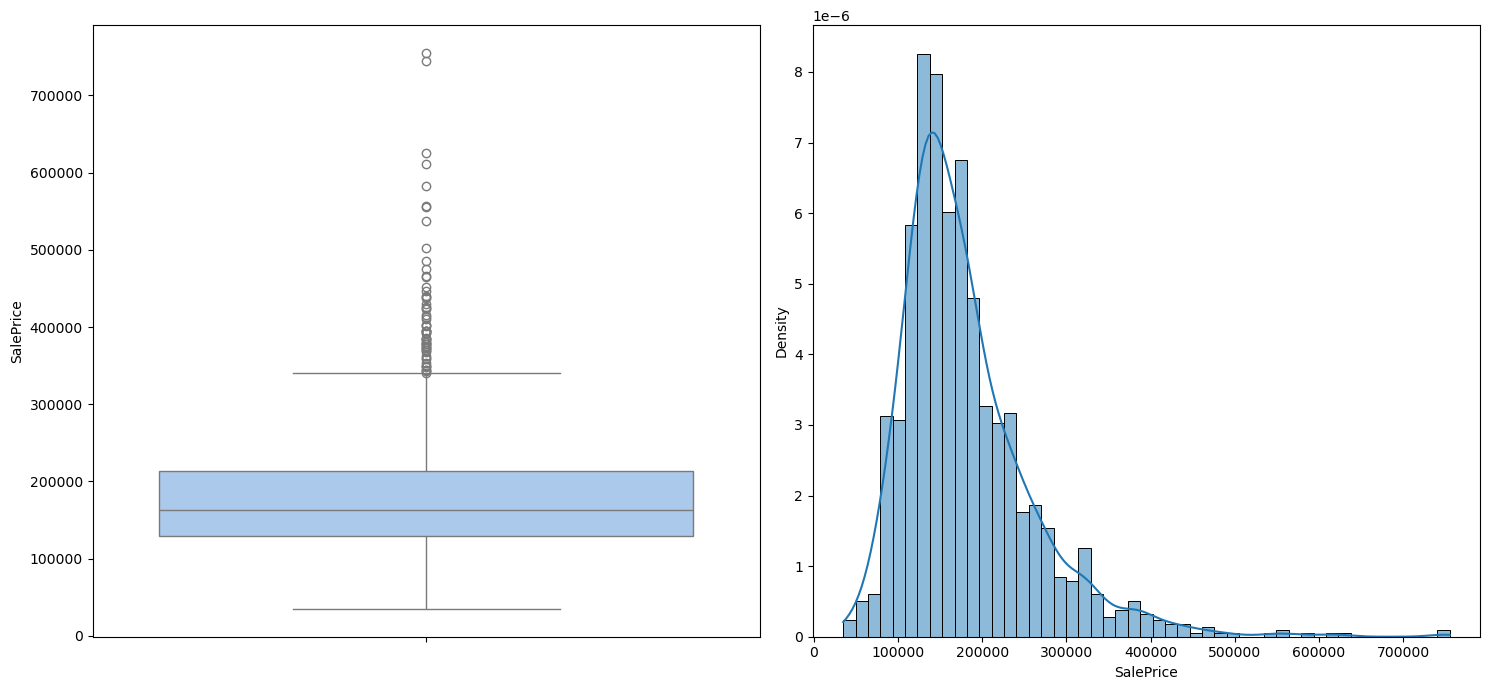

In [13]:
# plt.subplots(1, 2, figsize = (16, 8))

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

sns.boxplot(
    data = copy,
    y = "SalePrice",
    ax= ax[0],
    palette= "pastel"
)

sns.histplot(
    data= copy,
    x= "SalePrice",
    stat= "density",
    kde= True,
    palette= "pastel"
)
    
plt.tight_layout()
plt.show()

In [ ]:
q1, median, q3 = copy["SalePrice"].quantile([0.25, 0.5, 0.75])
IQR = q3 - q1 # Inter Quartile Range (IQR) => measures how spread out the central 50% of a dataset is
lower_bound = q1 - 1.5 * IQR # lower limit of the normal data range
upper_bound = q3 + 1.5 * IQR # upper limit of the normal data range

n_outlier = 0

# Filtering outliers
for value in copy["SalePrice"].values:
    if value < lower_bound or value > upper_bound:
        n_outlier += 1

variance = np.var(copy["SalePrice"])
std = np.sqrt(variance) # np.std(copy["SalePrice"])        

print(f"Q1 = {q1}  Median = {median}  Q3 = {q3}")
print(f"IQR(Inter Quartile Range) = {IQR}")
print(f"Lower Bound = {lower_bound:.3f}")
print(f"Upper Bound = {upper_bound:.3f}")
print(f"Number of Outliers = {n_outlier}")
print(f"Varinace = {variance}")
print(f"Standart Distribution = {std}")

skew = copy["SalePrice"].skew()
kurtosis = copy["SalePrice"].kurtosis()

print(f"Skewness = {skew}")
print(f"Kurtotsis = {kurtosis}") #

Q1 = 129975.0  Median = 163000.0  Q3 = 214000.0
IQR(Inter Quartile Range) = 84025.0
Lower Bound = 3937.500
Upper Bound = 340037.500
Number of Outliers = 61
Varinace = 6306788585.349301
Standart Distribution = 79415.29188606751
Skewness = 1.8828757597682129
Kurtotsis = 6.536281860064529


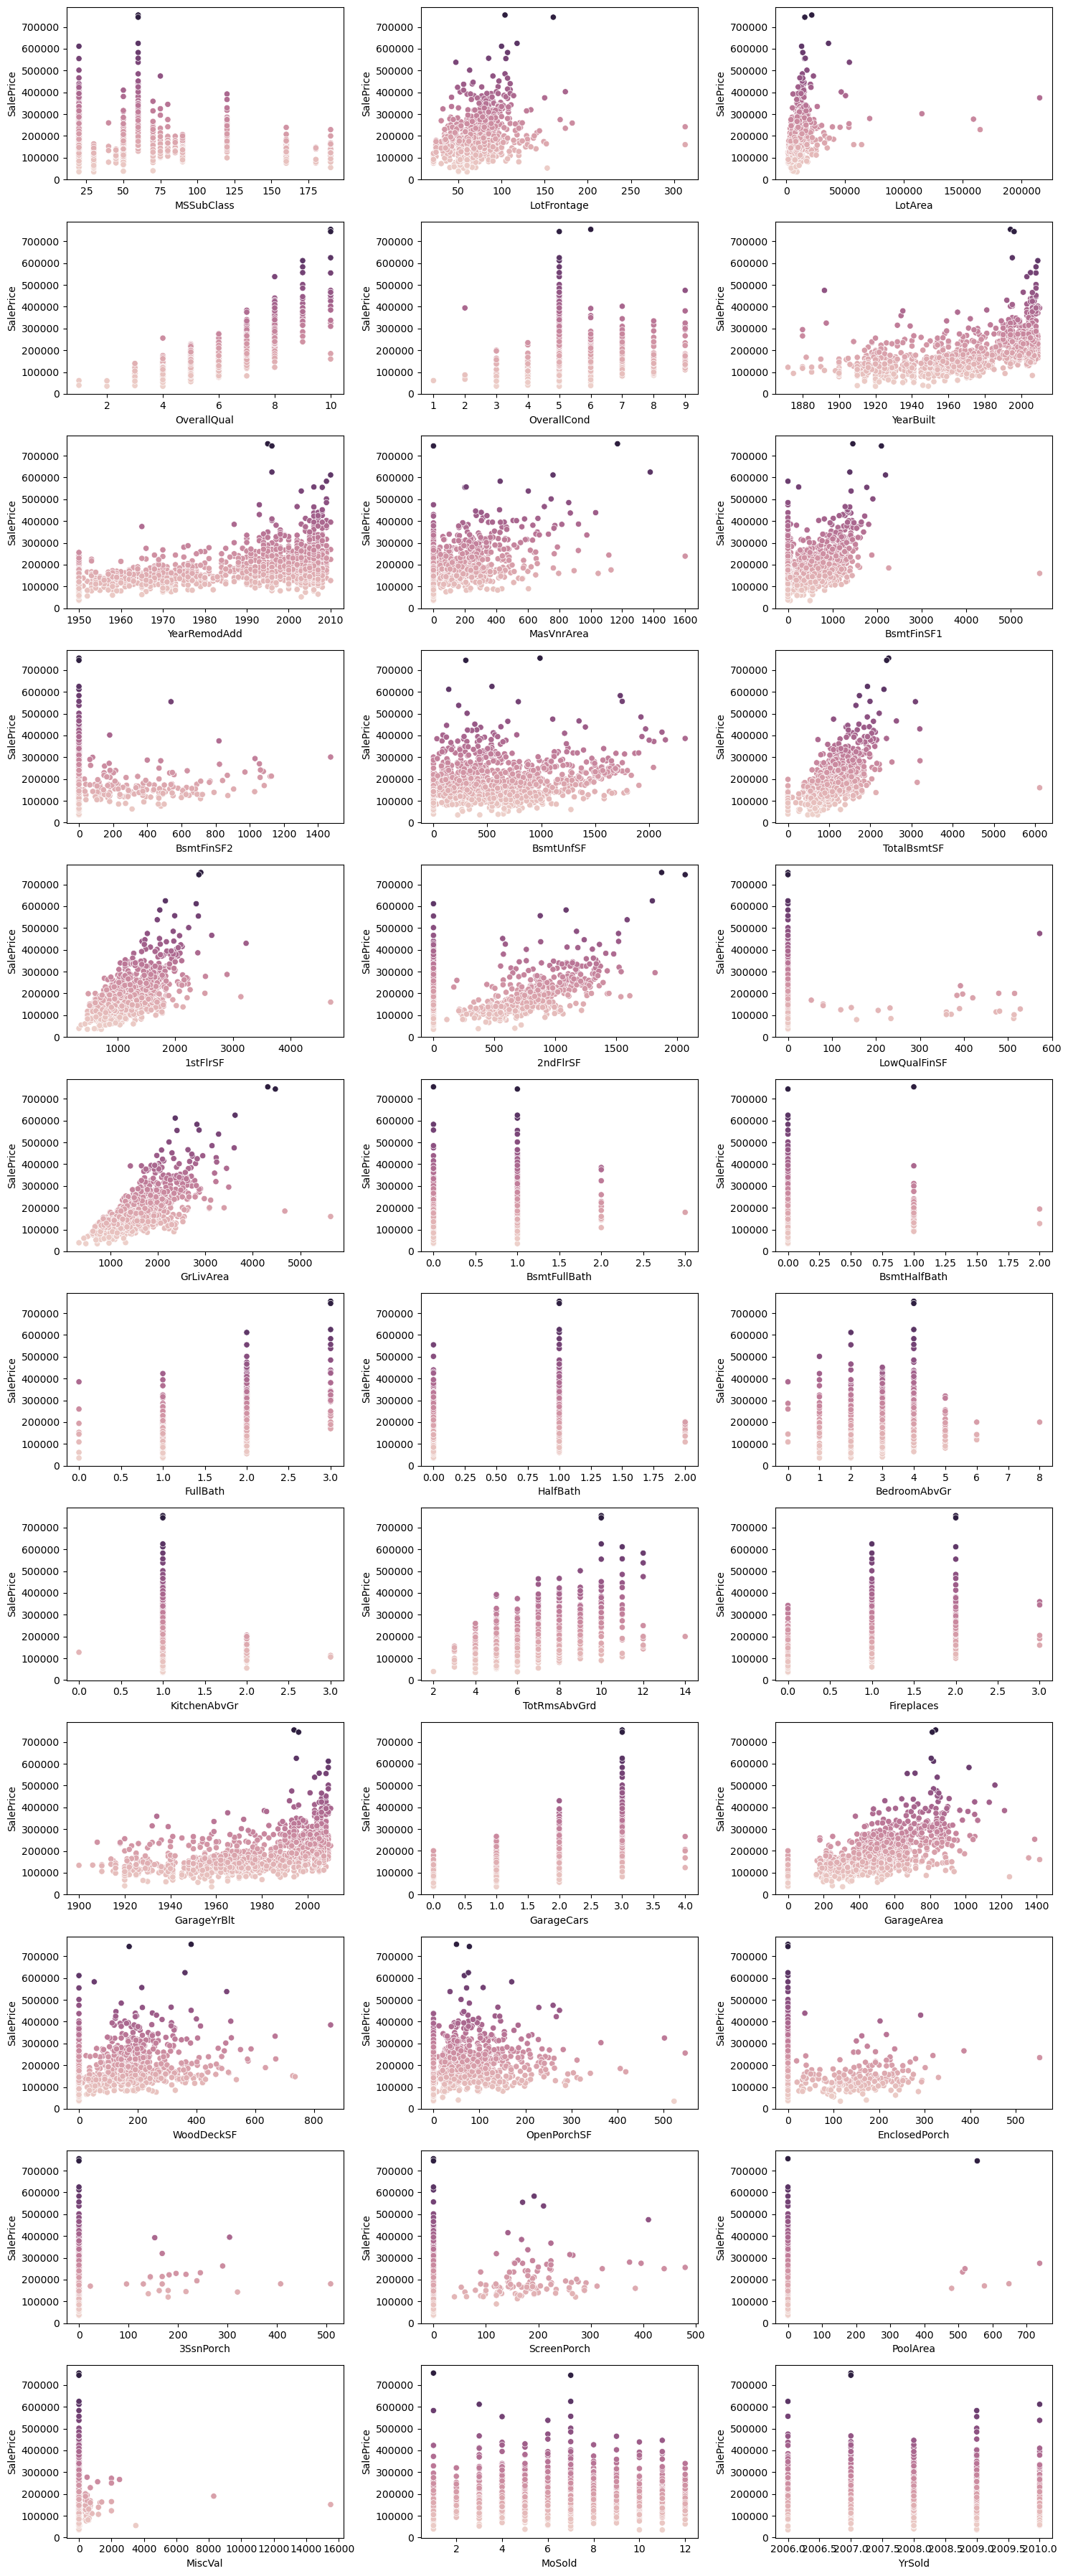

In [ ]:
numeric_features = get_numeric()

col = 3
row = math.ceil(len(numeric_features) / col)

fig , ax = plt.subplots(row, col , figsize = (15, row * 3))
ax = ax.ravel() # Converts the multi-dimensonal array ax intto a single-dimensonal array

for i , feature in enumerate(numeric_features):
    if feature != "SalePrice":
       sns.scatterplot(
            data= copy, 
            x= feature,
            y= "SalePrice",
            hue= "SalePrice",
            legend= None,
            ax= ax[i]
        )
    ax[i].tick_params("both", labelsize = 10)
    
plt.tight_layout()
plt.show()


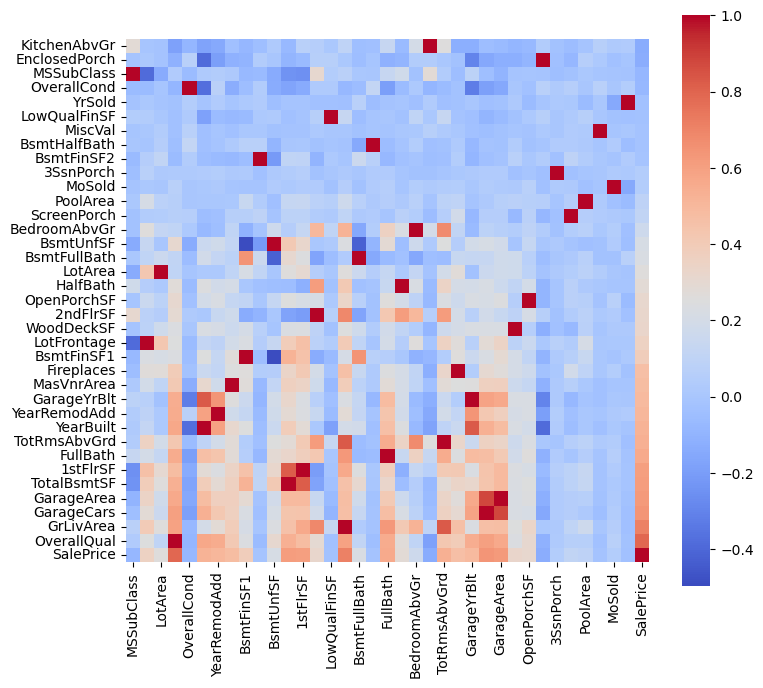

In [ ]:
# Correlations between Target and Numeric Features with Heatmap
corr = copy.corr(numeric_only= True).sort_values(by= "SalePrice")
plt.figure(figsize=(8, 7))
sns.heatmap(
    corr,
    cmap= "coolwarm",
    square= True
)

plt.tight_layout()
plt.show()

### Simple visualization of highly correlated features

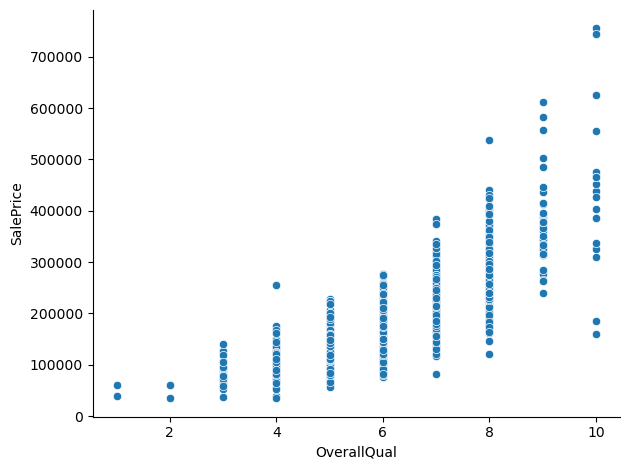

In [17]:
sns.scatterplot(
    data= copy,
    x= "OverallQual",
    y = "SalePrice"
)

sns.despine(trim= False)

plt.tight_layout()
plt.show()

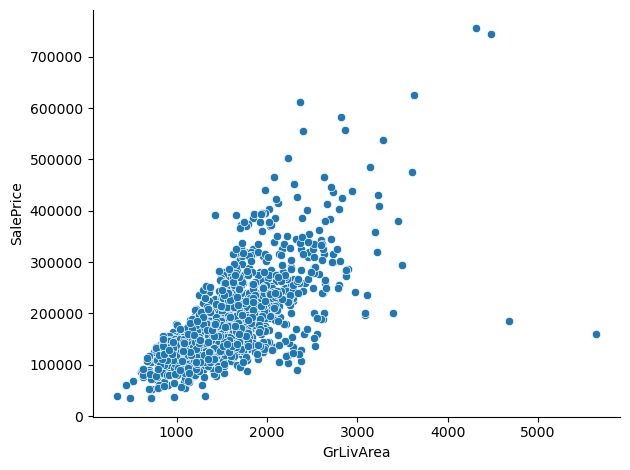

In [18]:
sns.scatterplot(
    data= copy,
    x= "GrLivArea",
    y = "SalePrice"
)

sns.despine(trim= False)

plt.tight_layout()
plt.show()

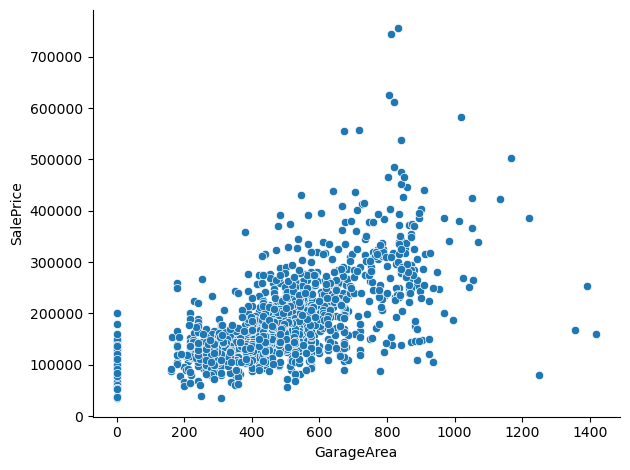

In [19]:
sns.scatterplot(
    data= copy,
    x= "GarageArea",
    y = "SalePrice"
)

sns.despine(trim= False)

plt.tight_layout()
plt.show()

### Normalizing the left-skewed Target

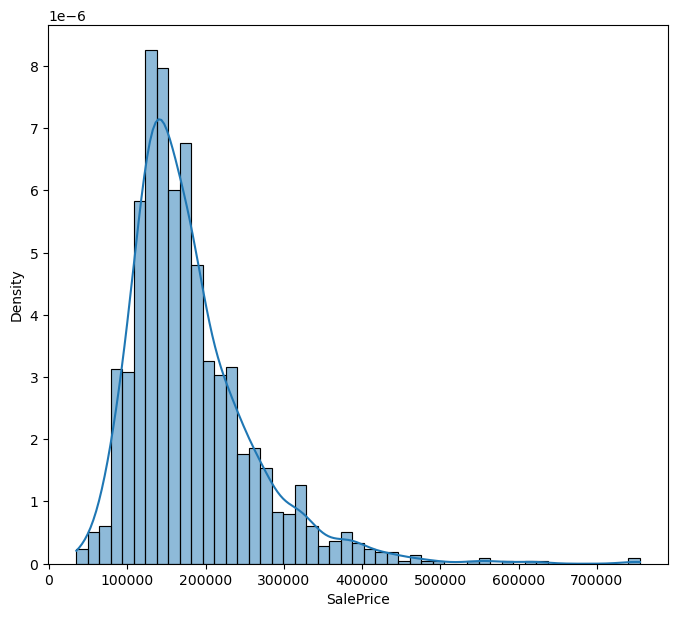

In [20]:
plt.figure(figsize= (8, 7))

sns.histplot(
    data = copy,
    x = "SalePrice",
    kde= True,  # Draw kde line
    stat= "density" # distribution denisty
)

plt.show()

**Skewness : Skewness measures the asymmetry of a data distribution** </br>
- positive skewness (> 0) : The distribution has along tail on the right side.Most of data values are small and a small number of values are very large
- negative skewness(< 0) : The distribution has along tail on the left side.Most of data values are large and a small number of values are very small

**Kurtosis : Kurtosis measures the “tailedness” of a distribution**
- kurtosis < 3 : thin tails , flat peak
- kurtosis = 3 : normal tails, normal peaks
- kurtosis > 3 : fat tails , high peak

In [21]:
skew = copy["SalePrice"].skew()
kurtosis = copy["SalePrice"].kurtosis()

print(f"Skewness = {skew}")
print(f"Kurtotsis = {kurtosis}") # 

Skewness = 1.8828757597682129
Kurtotsis = 6.536281860064529


**For better model accuracy , we must reduce skewness**
- The target variable (SalePrice) is right-skewed, contains outliers, and has high variance. Therefore, we will apply a log transformation to make it as close to a normal distribution as possible
- If we don't handle the skewness :
    * The model may focus too much on high values and leads to biased learning
    * Increases error metircs(MSE, RMSE, MAE...)
    * Violataes normality assumpstions because many model assume data is normally distributed

In [22]:
copy["SalePrice"] = np.log1p(copy["SalePrice"])

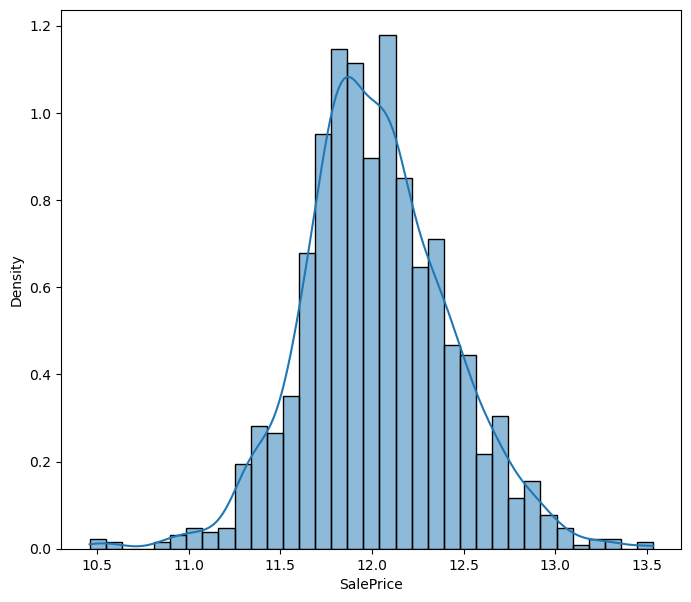

In [ ]:
# Visualization of the normalized Target
plt.figure(figsize= (8, 7))

sns.histplot(
    data = copy,
    x = "SalePrice",
    kde= True,  # Draw kde line
    stat= "density" # distribution denisty
)

plt.show()

In [51]:
skew = copy["SalePrice"].skew()
kurtosis = copy["SalePrice"].kurtosis()

print(f"Skewness = {skew}")
print(f"Kurtotsis = {kurtosis}") 

Skewness = 0.12134661989685333
Kurtotsis = 0.809519155707878


### Handling  Missing Values and Correcting Data Types

**MSSubClass , MoSold and YrSold are categoric variables but their type is Numeric**

- MSSubClass is a Categoric variable because the number which it countains represent different classes of houses, and the differences between these numbers do not indicate any ordinal relationshipr or magnitude

- YrSold and MoSold , these values indicate categories of time rather than magnitude, so the difference between years or month do not represent any meaningful numerical relationship


In [25]:
copy["MSSubClass"] = copy["MSSubClass"].astype(str)
copy["YrSold"] = copy["YrSold"].astype(str)
copy["MoSold"] = copy["MoSold"].astype(str)

In [26]:
all_features = pd.concat([copy, test], axis= 0, )

In [27]:
missings = get_missings(all_features)
missings[:15]

[('PoolQC', 99.66),
 ('MiscFeature', 96.4),
 ('Alley', 93.22),
 ('Fence', 80.44),
 ('MasVnrType', 60.5),
 ('FireplaceQu', 48.65),
 ('LotFrontage', 16.65),
 ('GarageYrBlt', 5.45),
 ('GarageFinish', 5.45),
 ('GarageQual', 5.45),
 ('GarageCond', 5.45),
 ('GarageType', 5.38),
 ('BsmtCond', 2.81),
 ('BsmtExposure', 2.81),
 ('BsmtQual', 2.77)]

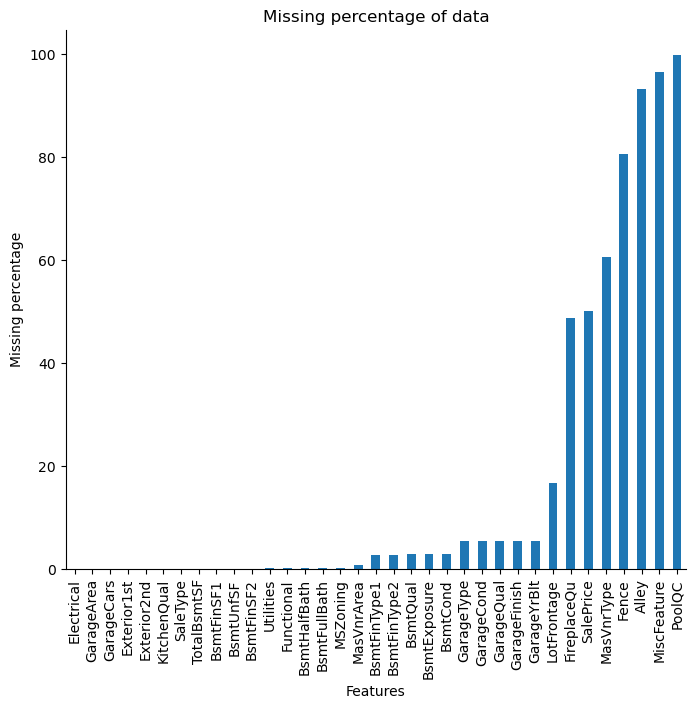

In [28]:
fig, ax = plt.subplots(figsize = (8, 7))

missing = round(all_features.isnull().mean()* 100 , 2)
missing = missing[missing > 0]
missing.sort_values(inplace= True) #inplace -> change the missing , do not create new variable
missing.plot(kind= "bar")
ax.set(xlabel= "Features")
ax.set(ylabel= "Missing percentage")
ax.set(title= "Missing percentage of data")

sns.despine(trim= False)

In [ ]:
#
all_features["Electrical"] = all_features["Electrical"].fillna("SBrkr")

all_features["KitchenQual"] = all_features["KitchenQual"].fillna("TA")

for i in ["MasVnrArea",  "BsmtFinSF2", "GarageYrBlt", "GarageArea"]:
    all_features[i] = all_features[i].fillna(0)

all_features["LotFrontage"] = all_features["LotFrontage"].fillna(
    all_features.groupby("Neighborhood")["LotFrontage"].transform("mean")
)

categoric = get_categoric(all_features)
numeric = get_numeric(all_features)

for i in categoric:
    all_features[i] = all_features[i].fillna("None")

for i in numeric:
    all_features[i] = all_features[i].fillna(0)   

In [30]:
missings = get_missings(all_features)
missings[:10]

[('MSSubClass', 0.0),
 ('MSZoning', 0.0),
 ('LotFrontage', 0.0),
 ('LotArea', 0.0),
 ('Street', 0.0),
 ('Alley', 0.0),
 ('LotShape', 0.0),
 ('LandContour', 0.0),
 ('Utilities', 0.0),
 ('LotConfig', 0.0)]

## Reducing Skewness of features

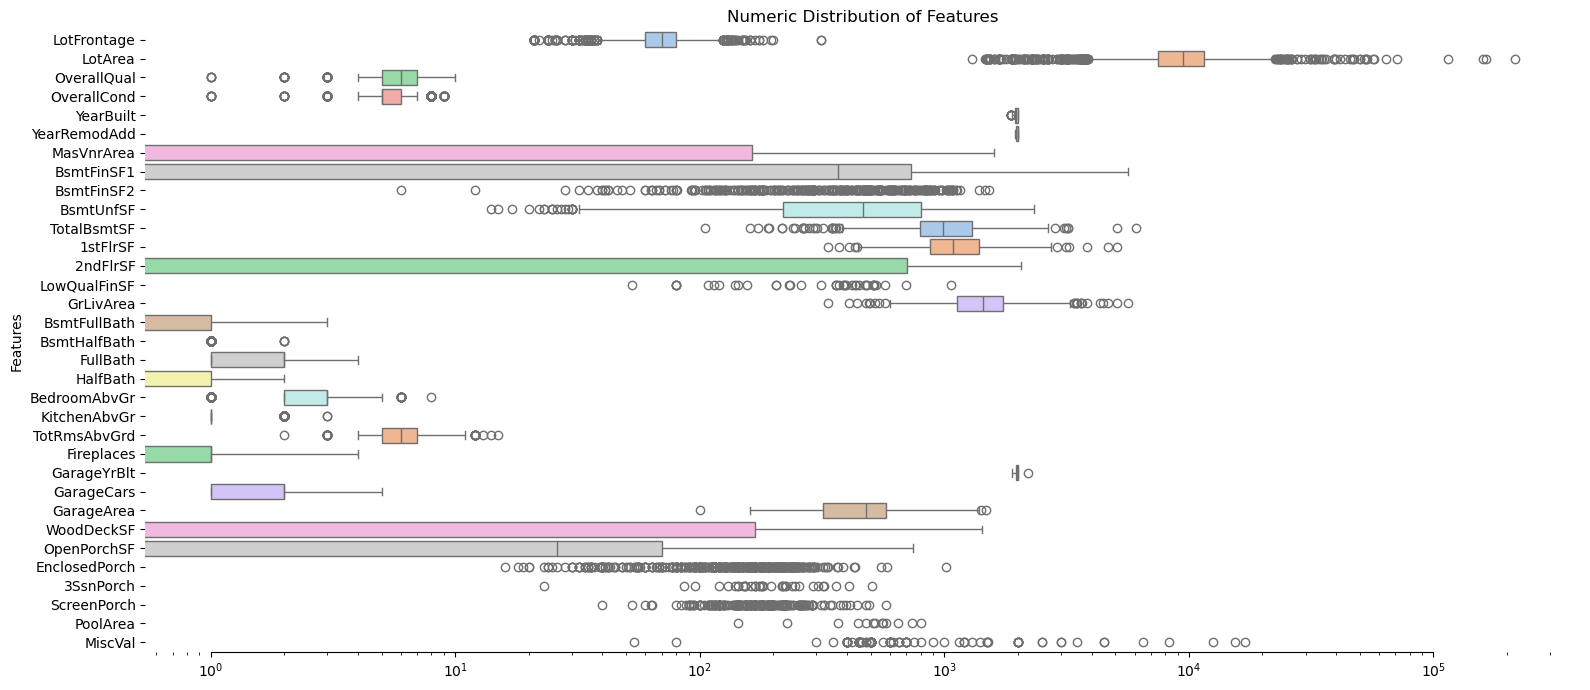

In [31]:
numeric = get_numeric(all_features)

fig, ax = plt.subplots(figsize = (16, 7))
ax.set_xscale("log")

ax = sns.boxplot(
    data= all_features[numeric],
    orient= "h",
    palette= "pastel",
)

sns.despine(trim= True, left= True)

ax.set(ylabel= "Features")
ax.set(title= "Numeric Distribution of Features")

plt.tight_layout()
plt.show()

In [32]:
feature_skew = all_features[numeric].skew().sort_values(ascending= False)

high_skewed = feature_skew[feature_skew > 0.5]

high_skewed_features = high_skewed.index

print(f"There are {high_skewed_features.shape[0]} features with Skew > 0.5")

high_skewed.head(10)

There are 25 features with Skew > 0.5


MiscVal          21.958480
PoolArea         16.907017
LotArea          12.829025
LowQualFinSF     12.094977
3SsnPorch        11.381914
KitchenAbvGr      4.304467
BsmtFinSF2        4.148275
EnclosedPorch     4.005950
ScreenPorch       3.948723
BsmtHalfBath      3.933616
dtype: float64

In [33]:
copy = all_features.iloc[:len(copy)]
test = all_features.iloc[len(copy): ]

In [34]:
copy[numeric] = pd.DataFrame(
    pt.fit_transform(copy[numeric]),
    columns= numeric,
    index= copy.index
)

test[numeric] = pd.DataFrame(
    pt.fit_transform(test[numeric]),
    columns= numeric,
    index= test.index
)

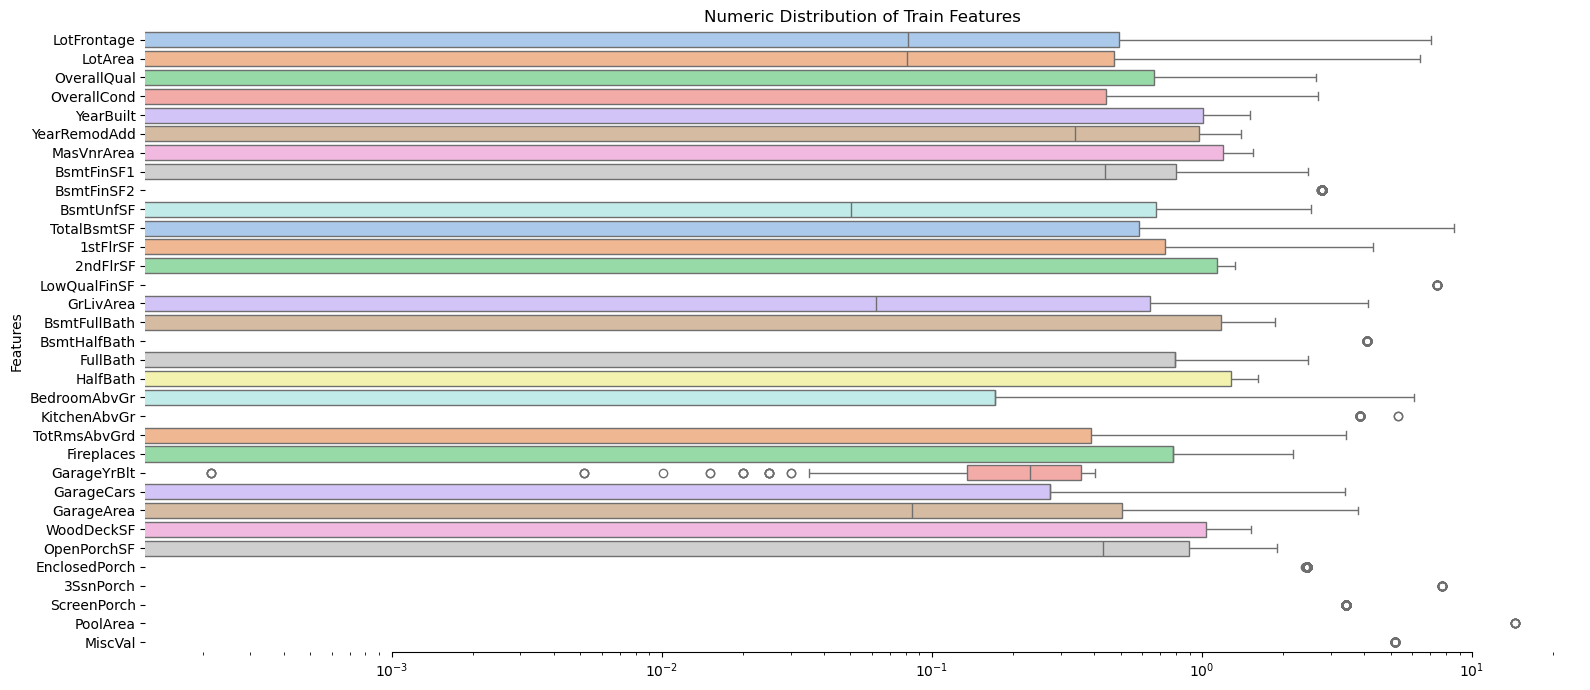

In [35]:
numeric = get_numeric(copy)

fig, ax = plt.subplots(figsize = (16, 7))
ax.set_xscale("log")

ax = sns.boxplot(
    data= copy[numeric],
    orient= "h",
    palette= "pastel",
)

sns.despine(trim= True, left= True)

ax.set(ylabel= "Features")
ax.set(title= "Numeric Distribution of Train Features")

plt.tight_layout()
plt.show()

In [36]:
skew = copy[numeric].skew()

skew.sort_values(ascending= False)[:10]

PoolArea         14.352680
3SsnPorch         7.613746
LowQualFinSF      7.299413
MiscVal           5.016528
BsmtHalfBath      3.859402
ScreenPorch       3.113266
BsmtFinSF2        2.425650
EnclosedPorch     2.047941
HalfBath          0.521435
MasVnrArea        0.426258
dtype: float64

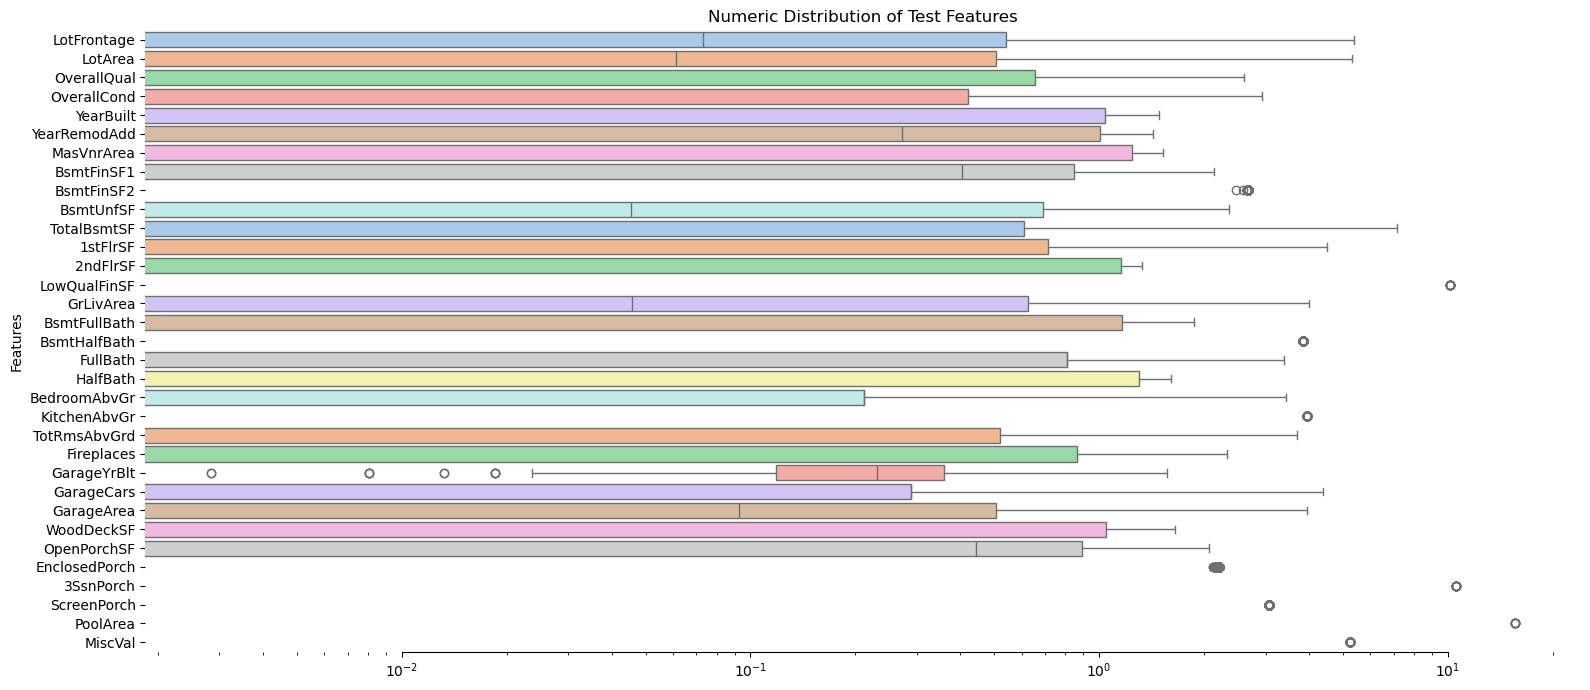

In [37]:
numeric = get_numeric(test)

fig, ax = plt.subplots(figsize = (16, 7))
ax.set_xscale("log")

ax = sns.boxplot(
    data= test[numeric],
    orient= "h",
    palette= "pastel",
)

sns.despine(trim= True, left= True)

ax.set(ylabel= "Features")
ax.set(title= "Numeric Distribution of Test Features")

plt.tight_layout()
plt.show()

In [38]:
skew = test[numeric].skew()

skew.sort_values(ascending= False)[:10]

PoolArea         15.513399
3SsnPorch        10.462542
LowQualFinSF     10.071370
MiscVal           5.069210
BsmtHalfBath      3.575267
ScreenPorch       2.746466
BsmtFinSF2        2.292974
EnclosedPorch     1.739874
HalfBath          0.547505
MasVnrArea        0.489905
dtype: float64

## Encoding

In [39]:
train_categoric = get_categoric(copy)

features_for_ordinal = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond' ]

features_for_target = []
features_for_OneHot = []

for feature in train_categoric:
    if feature in features_for_ordinal:
        continue

    if copy[feature].nunique() >= 10:
        features_for_target.append(feature)
    else:
        features_for_OneHot.append(feature)

In [40]:
#Ordinal Encoding
quality_map = {"None" : 0, 
              "Po" : 1, 
              "Fa" : 2, 
              "TA" : 3, 
              "Gd" : 4, 
              "Ex" : 5}

for feature in features_for_ordinal:
    copy[feature] = copy[feature].map(quality_map)
    test[feature] = test[feature].map(quality_map)


In [41]:
# Target Encoding
def cv_target_encoding(
    train,
    test,
    column,
    target_col,   
    n_splits=5,
    smoothing=10
):
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    train_encoded = pd.Series(index=train.index, dtype=float)

    global_mean = train[target_col].mean()

    for train_idx, val_idx in kf.split(train):

        X_train = train.iloc[train_idx]
        X_val = train.iloc[val_idx]

        y_train_fold = train.iloc[train_idx][target_col]

        stats = pd.concat(
            [X_train[column], y_train_fold],
            axis=1
        ).groupby(column)[target_col].agg(['mean', 'count'])

        smooth = (
            (stats['count'] * stats['mean']) +
            (smoothing * global_mean)
        ) / (stats['count'] + smoothing)

        train_encoded.iloc[val_idx] = (
            X_val[column]
            .map(smooth)
            .fillna(global_mean)
        )

    stats_full = pd.concat(
        [train[column], train[target_col]],
        axis=1
    ).groupby(column)[target_col].agg(['mean', 'count'])

    smooth_full = (
        (stats_full['count'] * stats_full['mean']) +
        (smoothing * global_mean)
    ) / (stats_full['count'] + smoothing)

    test_encoded = (
        test[column]
        .map(smooth_full)
        .fillna(global_mean)
    )

    return train_encoded, test_encoded

for feature in features_for_target:
    copy[feature], test[feature] = cv_target_encoding(
        train=copy,
        test=test,
        column=feature,
        target_col="SalePrice"   
    )

In [42]:
#OneHot-Encoding
all_features = pd.concat([copy, test], axis= 0)

all_features = pd.get_dummies(all_features , columns= features_for_OneHot, drop_first= True)

copy = all_features.iloc[:len(copy)]
test = all_features.iloc[len(copy):]

copy = copy.astype(float)
test = test.astype(float)

### Training and Evaluating the Models

In [43]:
y_train = copy["SalePrice"]
X_train = copy.drop(["SalePrice"], axis= 1,)
X_test = test
y_test = samples

In [44]:
regression = LinearRegression()
lasso, lassoCV = Lasso(), LassoCV()
ridge , ridgeCV = Ridge(), RidgeCV()
elastic, elasticCV = ElasticNet(), ElasticNetCV()

In [50]:
def pipeLine(X_train, y_train):
    models = (regression, lasso, lassoCV, ridge, ridgeCV, elastic, elasticCV)

    for model in models:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        # pipeline.fit(X_train, y_train)
        r2_score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
        # score = pipeline.score(X_test, y_test)

        print(f"Model : {model.__class__.__name__}\n\n" +
              f"R2 score : {r2_score.mean():.4f} ± {r2_score.std():.4f}\n")

        print("=" * 50)

pipeLine(X_train, y_train)


Model : LinearRegression

R2 score : 0.8162 ± 0.0920

Model : Lasso

R2 score : -0.0035 ± 0.0051

Model : LassoCV

R2 score : 0.8921 ± 0.0203

Model : Ridge

R2 score : 0.8357 ± 0.0791

Model : RidgeCV

R2 score : 0.8649 ± 0.0309

Model : ElasticNet

R2 score : -0.0035 ± 0.0051

Model : ElasticNetCV

R2 score : 0.8922 ± 0.0204

